In [1]:
import sunpy
import sunpy.map
from matplotlib import colormaps as cm
from matplotlib.collections import LineCollection
import astropy.units as u
from astropy.time import Time
from astropy.visualization import ImageNormalize, AsinhStretch
from astropy.io import ascii, fits
from map_coalign import MapSequenceCoalign
import numpy as np
import importlib
from image_wavelet import WPSImage
from glob import glob
from copy import deepcopy
import plotly.graph_objects as go
import matplotlib.pyplot as plt


import dask.array as da
import h5py
import dkist 
from ndcube import NDCube
import cmcrameri.cm as cmcm

In [2]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [3]:
Hbeta_pr_da.shape

(282, 3840, 3840)

In [4]:
Hbeta_pr_da_rebin = np.mean(Hbeta_pr_da.reshape((Hbeta_pr_da.shape[0], Hbeta_pr_da.shape[1]//4, 4, Hbeta_pr_da.shape[2]//4, 4)), axis=(2, 4))

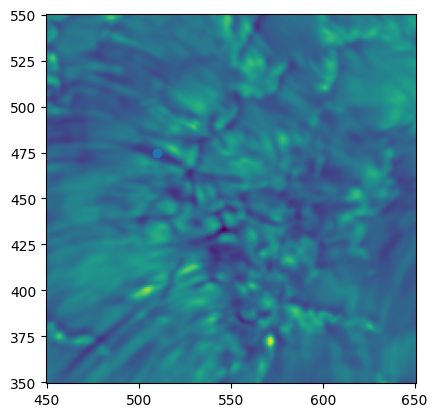

In [5]:
fig, ax = plt.subplots()
ax.imshow(Hbeta_pr_da_rebin[0,350:550,450:650], origin="lower",
extent=[450-0.5, 650+0.5, 350-0.5, 550+0.5])
ax.scatter(510, 475)

In [6]:
time = np.arange(Hbeta_pr_da.shape[0])*9.14
scales = 9.14*np.logspace(1, 7,num=30, base=2)

In [7]:
Hbeta_pr_da_wps = WPSImage(scales, Hbeta_pr_da_rebin.transpose(1,2,0), time,lag1=0.72)

In [8]:
Hbeta_pr_da_wps._wps_image(ncpu=8)

/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:1

In [9]:
Hbeta_pr_da_wps.global_ws_unbias.shape

(960, 960, 30)

In [10]:
print(np.argmin(np.abs(scales - 120)))
print(np.argmin(np.abs(scales - 180)))
print(np.argmin(np.abs(scales - 240)))
print(np.argmin(np.abs(scales - 300)))

13
16
18
19


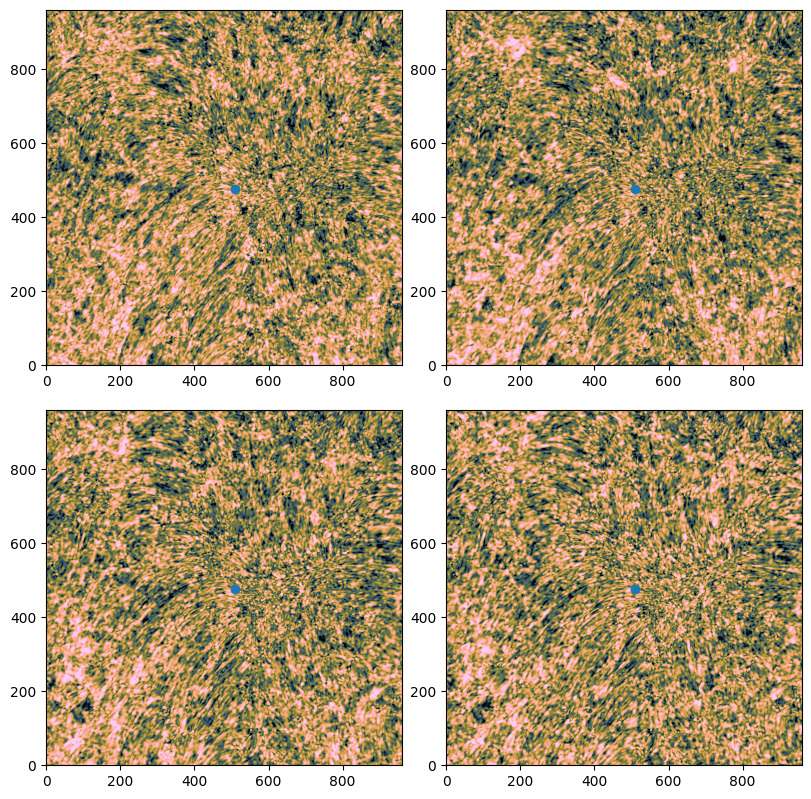

In [15]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(8,8), layout="constrained")

ax1.imshow(Hbeta_pr_da_wps.global_ws_unbias[:,:,13], origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,13], 1),
           vmax=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,13], 99),stretch=AsinhStretch()),
           cmap=cmcm.batlowK)
ax2.imshow(Hbeta_pr_da_wps.global_ws_unbias[:,:,16], origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,16], 1),
           vmax=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,16], 99),stretch=AsinhStretch()),
           cmap=cmcm.batlowK)
ax3.imshow(Hbeta_pr_da_wps.global_ws_unbias[:,:,18], origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,18], 1),
           vmax=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,18], 99),stretch=AsinhStretch()),
           cmap=cmcm.batlowK)
ax4.imshow(Hbeta_pr_da_wps.global_ws_unbias[:,:,19], origin="lower",
           norm=ImageNormalize(vmin=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,19], 1),
           vmax=np.nanpercentile(Hbeta_pr_da_wps.global_ws_unbias[:,:,19], 99),stretch=AsinhStretch()),
           cmap=cmcm.batlowK)

for ax_ in (ax1,ax2,ax3,ax4):
    ax_.scatter(510, 475)

/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:150: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi = np.nanmean(power_unbias_coi, axis=1)
/cluster/home/zhuyin/scripts/MyPy/image_wavelet.py:151: RuntimeWarning: Mean of empty slice
  global_ws_unbias_coi_sig = np.nanmean(power_unbias_coi_sig, axis=1)


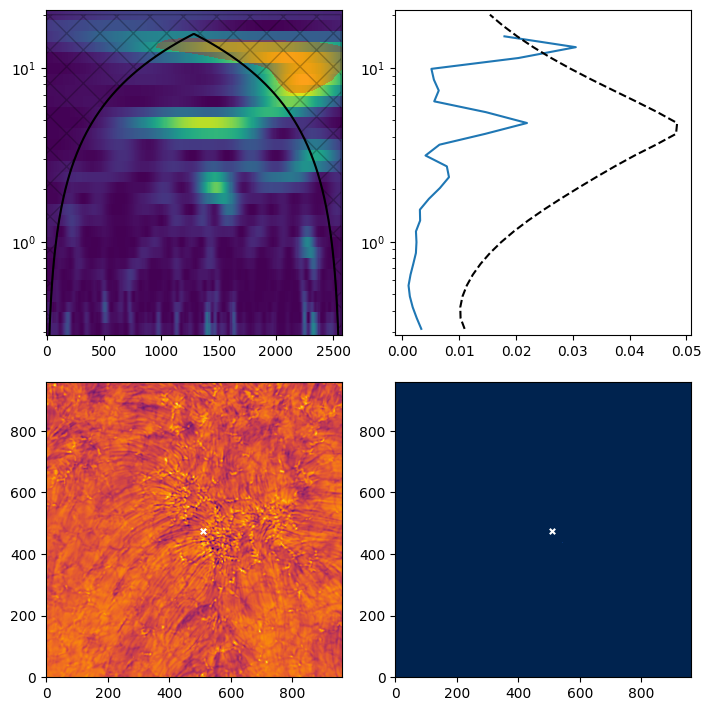

In [12]:
Hbeta_pr_da_wps.plot_single_ws(510, 475)

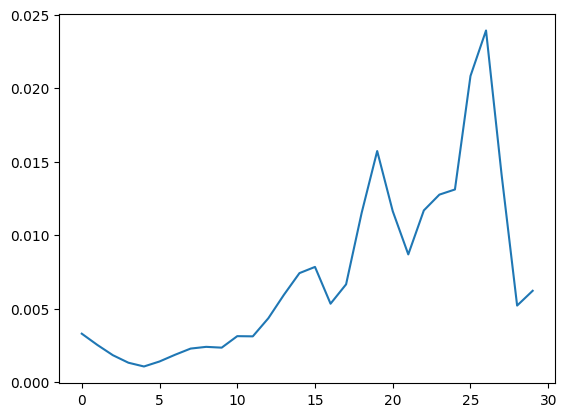

In [14]:
plt.plot(Hbeta_pr_da_wps.global_ws_unbias[475,510,:])
